# PSYC0021: Tutorial to Build Automatic Exertion Detection Algorithm using PPG Features

## Mount Google Drive

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
os.chdir("drive/My Drive/Colab/PPG_Feature_Extraction_Example/02_automatic_exertion_level_recognition_using_ppg_data")

Mounted at /content/drive


## Install HeartPy Package

In [2]:
! pip install heartpy

## Import packages

In [3]:
%matplotlib inline
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option("display.precision", 2)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from utils.process_ppg import load_dataframe

## Load the features
Check the dataframe

In [ ]:
fpath = os.path.join('data', 'mydata', 'PPG_features.pkl')

In [10]:
df, ppg_df = load_dataframe(fpath)
# df = pd.read_pickle(fpath)
# ppg_df

In [11]:
df

,p007_ppgSignal_moderate.csv,p007_ppgSignal_low.csv,p004_ppgSignal_low.csv,p004_ppgSignal_moderate.csv,p006_ppgSignal_moderate.csv,p006_ppgSignal_low.csv,p003_ppgSignal_low.csv,p003_ppgSignal_moderate.csv,p002_ppgSignal_moderate.csv,p002_ppgSignal_low.csv,...,s001_ppgSignal_low_2021-02-04 142801.712320.csv,s001_ppgSignal_high_2021-03-13 19_33_21.csv,s001_ppgSignal_low_2021-03-04 221859.334287.csv,s001_ppgSignal_high_2021-03-17 23_49_47.csv,s002_ppgSignal_moderate_2021-03-13 133205.210364.csv,s002_ppgSignal_moderate_2021-03-16 15_01_19.396316.csv,s002_ppgSignal_high_2021-03-16 101045.157893.csv,s002_ppgSignal_low_2021-02-05 212424.923846.csv,s002_ppgSignal_high_2021-03-16 101241.783247.csv,s002_ppgSignal_low_2021-03-11 231527.775965.csv
wd,"{'hr': [0.7594222697982929, 0.6733973785058514...","{'hr': [0.8570997577901284, 0.8448210565071005...","{'hr': [0.15747397447049677, 0.213833176853288...","{'hr': [0.2812412971250921, 0.3531759075505119...","{'hr': [4.244046663196862, 3.4604620454783626,...","{'hr': [0.28707884890963015, 0.295498731238106...","{'hr': [0.6595737610652421, 0.818806460622659,...","{'hr': [0.2177023673967115, 0.2398605267811668...","{'hr': [0.6325125750882414, 0.6155038207347807...","{'hr': [0.25357961553984, 0.38568311869209504,...",...,"{'hr': [0.35669249374592515, 0.372896983025378...","{'hr': [2.264829213911505, 2.079303059728889, ...","{'hr': [5.381557653540629, 4.385685091791103, ...","{'hr': [0.3089393441560048, 0.4417771417538493...","{'hr': [1.669375296246167, 1.8347240657299873,...","{'hr': [0.7927493515962154, 1.0985031197304687...","{'hr': [4.735665367129817, 3.9120236599291647,...","{'hr': [1.682650425140893, 1.5605218034613362,...","{'hr': [1.478153831892655, 1.4093881374205552,...","{'hr': [1.8984477968942781, 2.013631996601002,..."
m,"{'bpm': 138.28715365239296, 'ibi': 433.8797814...","{'bpm': 91.85905224787363, 'ibi': 653.17460317...","{'bpm': 160.29684601113175, 'ibi': 374.3055555...","{'bpm': 159.00339750849378, 'ibi': 377.3504273...","{'bpm': 113.04347826086955, 'ibi': 530.7692307...","{'bpm': 72.46753246753246, 'ibi': 827.95698924...","{'bpm': 151.52394775036285, 'ibi': 395.9770114...","{'bpm': 120.41166380789022, 'ibi': 498.2905982...","{'bpm': 102.32558139534885, 'ibi': 586.3636363...","{'bpm': 65.75342465753425, 'ibi': 912.5, 'sdnn...",...,"{'bpm': 63.63636363636363, 'ibi': 942.85714285...","{'bpm': 86.59793814432989, 'ibi': 692.85714285...","{'bpm': 60.0, 'ibi': 1000.0, 'sdnn': 72.648315...","{'bpm': 70.07299270072993, 'ibi': 856.25, 'sdn...","{'bpm': 93.4487021013597, 'ibi': 642.063492063...","{'bpm': 90.60402684563759, 'ibi': 662.22222222...","{'bpm': 107.75510204081631, 'ibi': 556.8181818...","{'bpm': 90.51428571428573, 'ibi': 662.87878787...","{'bpm': 103.56731875719217, 'ibi': 579.3333333...","{'bpm': 75.26881720430107, 'ibi': 797.14285714..."


### Drop parameters from dataframe (e.g. sub_id)

In [12]:
ppg_df = ppg_df.drop(columns=['sub_id','s'])
ppg_df.head()

,exertion_level,bpm,ibi,sdnn,sdsd,rmssd,pnn20,pnn50,hr_mad,sd1,sd2,sd1/sd2,breathingrate
0,moderate,138.29,433.88,66.53,77.95,98.80,0.77,0.38,33.33,69.78,60.73,1.15,0.34
1,low,91.86,653.17,78.02,56.67,84.98,0.85,0.45,33.33,60.05,93.39,0.64,0.18
2,low,160.30,374.31,93.10,70.18,122.17,0.89,0.73,50.00,85.99,65.15,1.32,0.11
3,moderate,159.00,377.35,31.80,28.37,38.18,0.56,0.16,16.67,26.99,36.22,0.75,0.31
4,moderate,113.04,530.77,53.05,29.16,69.39,1.00,0.56,33.33,49.00,65.73,0.75,0.29


## Inspect features

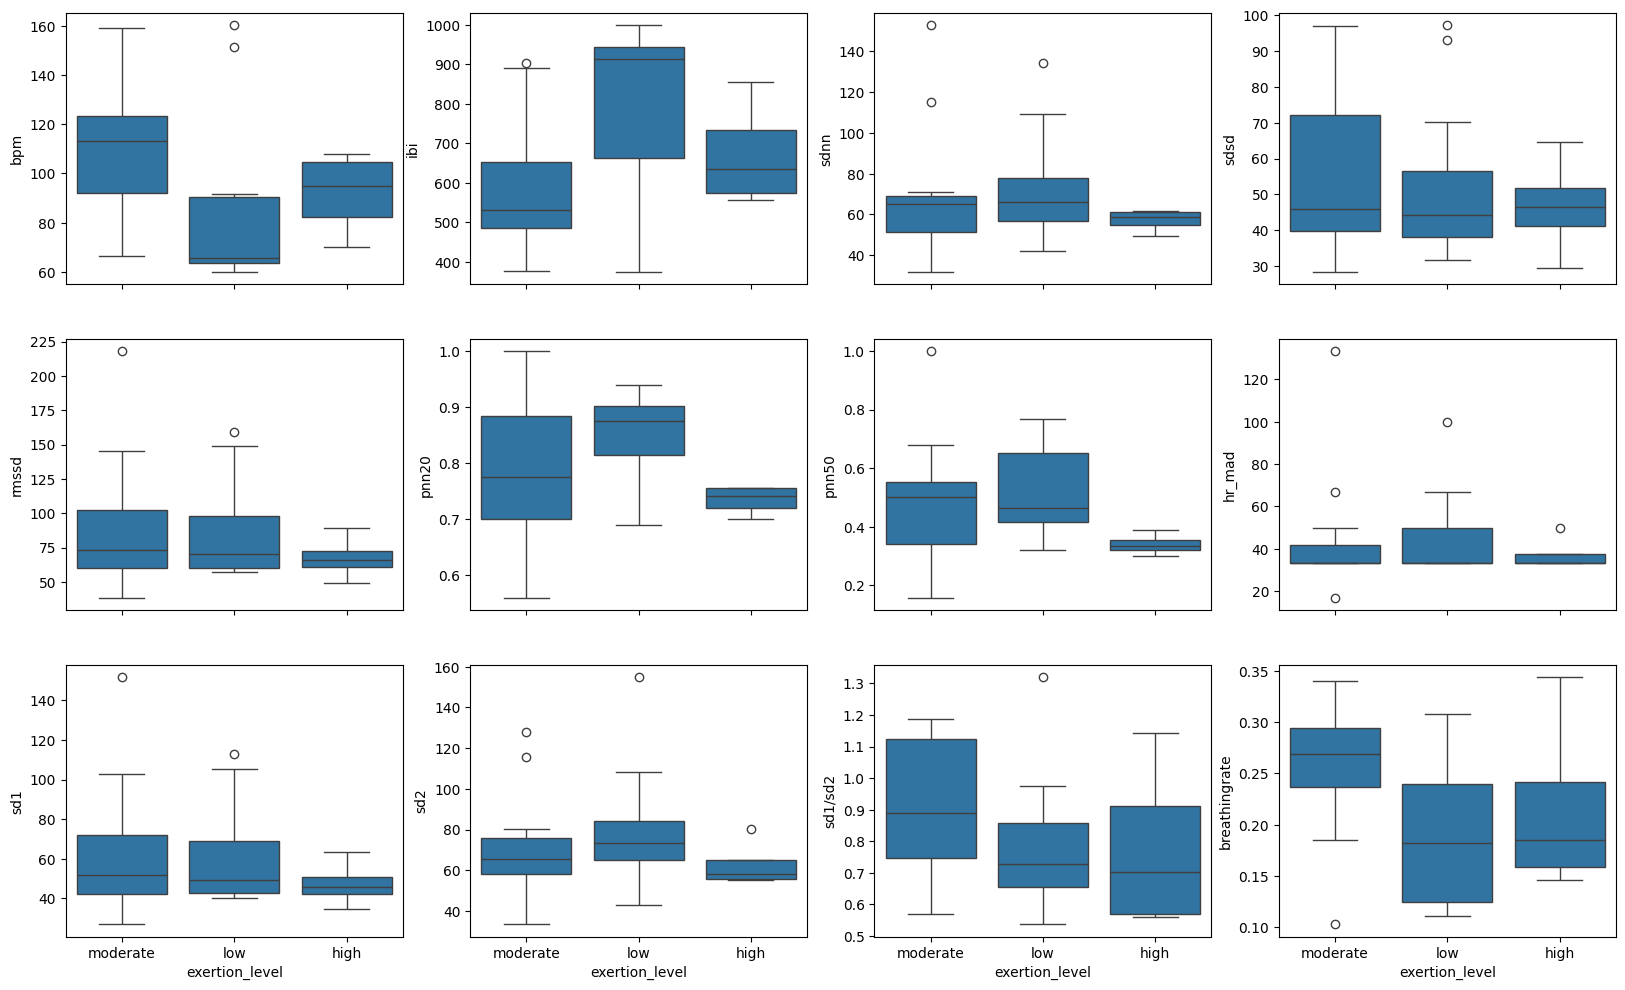

In [13]:
params = ['bpm', 'ibi', 'sdnn', 'sdsd', 'rmssd','pnn20', 'pnn50',
'hr_mad', 'sd1', 'sd2', 'sd1/sd2', 'breathingrate']
fig, ax = plt.subplots(3, 4, figsize=(20, 12), sharex=True)
for idx in range(len(params)):
    plt.subplot(3,4,idx+1)
    sns.boxplot(x="exertion_level", y=params[idx], data=ppg_df)
plt.show()

## Preparing the data, transforming the labels into number, so they are readable by ML algorithm

In [14]:
targets, targets_index = pd.factorize(ppg_df['exertion_level'])
print(targets)
print(targets_index)

[0 1 1 0 0 1 1 0 0 1 1 0 1 0 0 1 0 1 1 2 1 2 0 0 2 1 2 1]
Index(['moderate', 'low', 'high'], dtype='object')


## Split data into training and testing sets (80% v/s 20%)

In [15]:
features = ppg_df.columns[1:]
ppg_df['is_train'] = np.random.uniform(0, 1, len(ppg_df)) <= .80

# Create two new dataframes, one with the training rows, one with the test rows
train, test = ppg_df[ppg_df['is_train']==True], ppg_df[ppg_df['is_train']==False]
train_target = targets[ppg_df['is_train']==True]
test_target = targets[ppg_df['is_train']==False]

## Train Random Forest Classifier

In [16]:
# Create a random forest Classifier
clf = RandomForestClassifier(n_jobs=2, random_state=0)

# Train the Classifier
clf.fit(train[features], train_target)

RandomForestClassifier(n_jobs=2, random_state=0)

### Train SVM Classifier [Optional]

In [17]:
# clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
# # Train the Classifier
# clf.fit(train[features], train_target)

## Evaluate the trained classifier on test data

In [18]:
test_pred = clf.predict(test[features])
test_pred_prob = clf.predict_proba(test[features])

### Normalized Confusion Matrix

              precision    recall  f1-score   support

           0       0.67      0.40      0.50         5
           1       0.25      0.50      0.33         2

    accuracy                           0.43         7
   macro avg       0.46      0.45      0.42         7
weighted avg       0.55      0.43      0.45         7



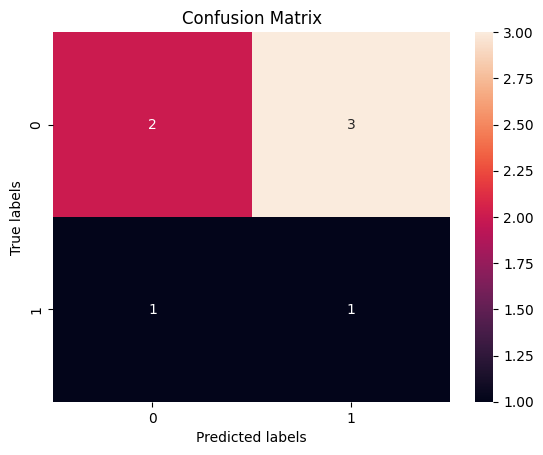

In [19]:
# Generate Confusion Matrix
cm = confusion_matrix(test_target, test_pred, normalize=None)
ax= plt.subplot()
print(classification_report(test_target, test_pred))

sns.heatmap(cm, annot=True, ax = ax, fmt='g') #annot=True to annotate cells
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
plt.show()